Single Layer Perceptron - LOGIC Gates

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, n_inputs, lr=0.1):
        # weights[0] is the bias, weights[1:] are the input weights
        self.weights = np.zeros(n_inputs + 1)
        self.lr = lr
        self.history = [self.weights.copy()]  # track weights after every update

    def activation(self, x):
        return 1 if x >= 0 else 0

    def predict(self, x):
        z = np.dot(self.weights[1:], x) + self.weights[0]
        return self.activation(z)

    def train(self, X, y, epochs=10, gate_name="Gate", plot_every_update=True):
        for epoch in range(epochs):
            for xi, target in zip(X, y):
                pred = self.predict(xi)
                error = target - pred
                if error != 0:
                    self.weights[1:] += self.lr * error * xi
                    self.weights[0]  += self.lr * error
                    self.history.append(self.weights.copy())
                    print(f"Epoch {epoch+1}, input {xi}, target {target}, "
                          f"pred {pred} -> updated weights: {self.weights}")
                    if plot_every_update:
                        self.plot_boundary(X, y, gate_name)

    def plot_boundary(self, X, y, gate_name):
        n_features = X.shape[1]
        if n_features == 2:
            self._plot_2d(X, y, gate_name)
        elif n_features == 1:
            self._plot_1d(X, y, gate_name)

    def _plot_2d(self, X, y, gate_name):
        plt.figure(figsize=(4, 4))
        for xi, target in zip(X, y):
            marker = 'o' if target == 1 else 'x'
            color = 'blue' if target == 1 else 'red'
            plt.scatter(xi[0], xi[1], marker=marker, c=color, s=100)

        w0, w1, w2 = self.weights
        x_vals = np.array([-0.5, 1.5])
        if w2 != 0:
            y_vals = -(w0 + w1 * x_vals) / w2
            plt.plot(x_vals, y_vals, 'k--')
        elif w1 != 0:
            x_line = -w0 / w1
            plt.axvline(x_line, color='k', linestyle='--')

        plt.xlim(-0.5, 1.5)
        plt.ylim(-0.5, 1.5)
        plt.title(f"{gate_name} — weights: {np.round(self.weights, 2)}")
        plt.xlabel("x1")
        plt.ylabel("x2")
        plt.grid(True)
        plt.show()

    def _plot_1d(self, X, y, gate_name):
        plt.figure(figsize=(4, 2))
        for xi, target in zip(X, y):
            color = 'blue' if target == 1 else 'red'
            plt.scatter(xi[0], 0, c=color, s=100)

        w0, w1 = self.weights
        if w1 != 0:
            boundary = -w0 / w1
            plt.axvline(boundary, color='k', linestyle='--')

        plt.xlim(-0.5, 1.5)
        plt.title(f"{gate_name} — weights: {np.round(self.weights, 2)}")
        plt.yticks([])
        plt.xlabel("x1")
        plt.grid(True)
        plt.show()

OR Gate


Epoch 1, input [0 0], target 0, pred 1 -> updated weights: [-0.1  0.   0. ]


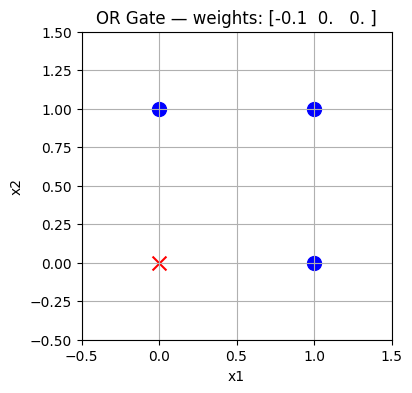

Epoch 1, input [0 1], target 1, pred 0 -> updated weights: [0.  0.  0.1]


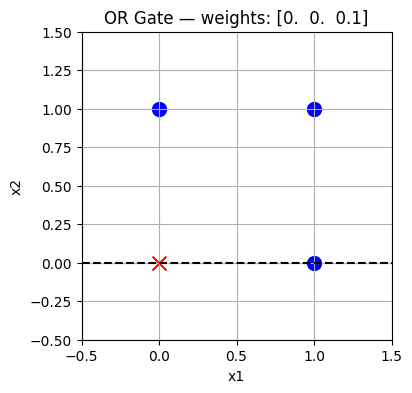

Epoch 2, input [0 0], target 0, pred 1 -> updated weights: [-0.1  0.   0.1]


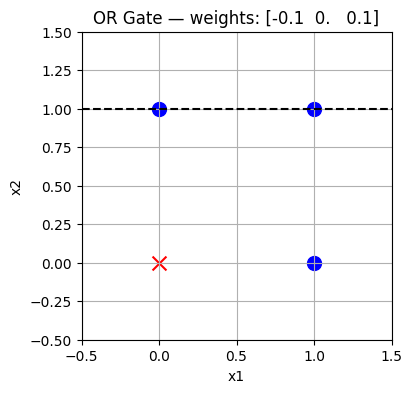

Epoch 2, input [1 0], target 1, pred 0 -> updated weights: [0.  0.1 0.1]


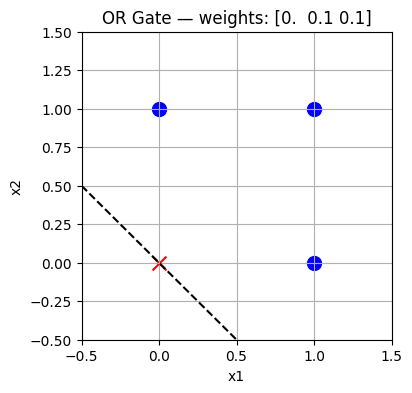

Epoch 3, input [0 0], target 0, pred 1 -> updated weights: [-0.1  0.1  0.1]


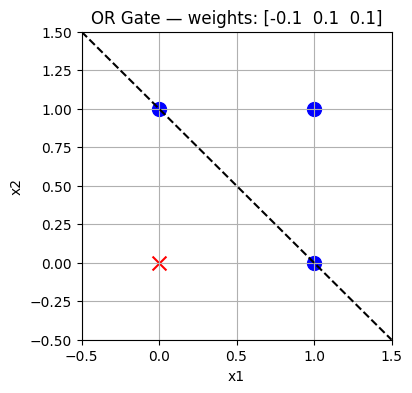

In [ ]:
X_or = np.array([[0,0],[0,1],[1,0],[1,1]])
y_or = np.array([0,1,1,1])

p_or = Perceptron(n_inputs=2, lr=0.1)
p_or.train(X_or, y_or, epochs=5, gate_name="OR Gate")

AND Gate

Epoch 1, input [0 0], target 0, pred 1 -> updated weights: [-0.1  0.   0. ]


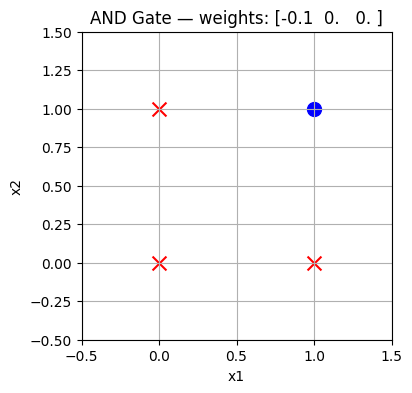

Epoch 1, input [1 1], target 1, pred 0 -> updated weights: [0.  0.1 0.1]


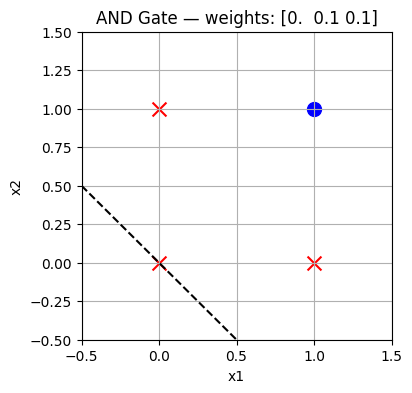

Epoch 2, input [0 0], target 0, pred 1 -> updated weights: [-0.1  0.1  0.1]


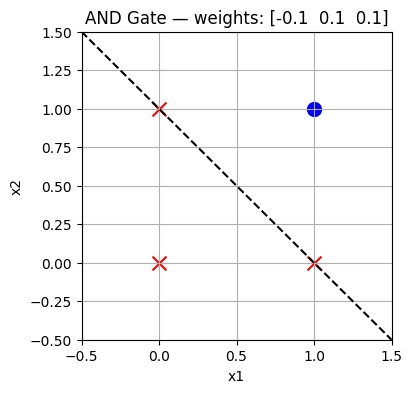

Epoch 2, input [0 1], target 0, pred 1 -> updated weights: [-0.2  0.1  0. ]


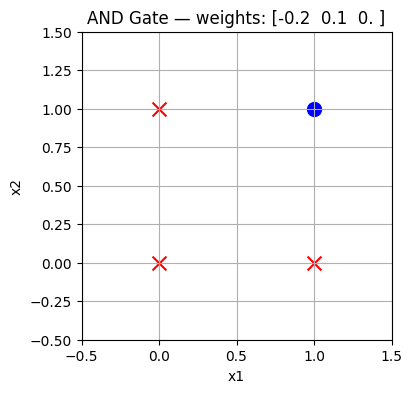

Epoch 2, input [1 1], target 1, pred 0 -> updated weights: [-0.1  0.2  0.1]


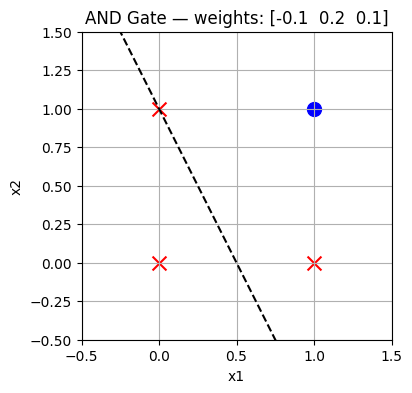

Epoch 3, input [0 1], target 0, pred 1 -> updated weights: [-0.2  0.2  0. ]


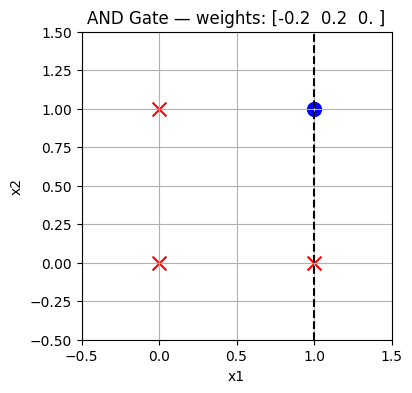

Epoch 3, input [1 0], target 0, pred 1 -> updated weights: [-0.3  0.1  0. ]


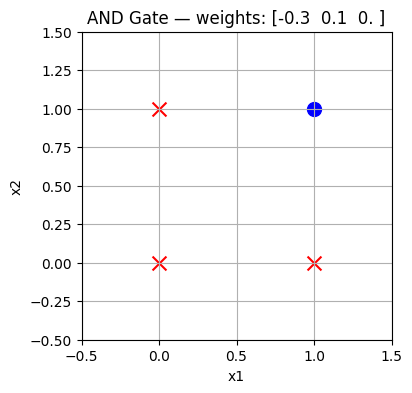

Epoch 3, input [1 1], target 1, pred 0 -> updated weights: [-0.2  0.2  0.1]


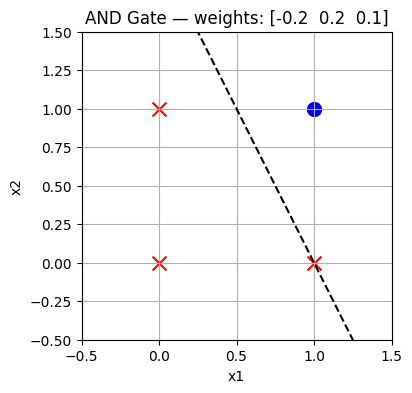

In [ ]:
X_and = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0,0,0,1])

p_and = Perceptron(n_inputs=2, lr=0.1)
p_and.train(X_and, y_and, epochs=10, gate_name="AND Gate")

NOT Gate

Epoch 1, input [1], target 0, pred 1 -> updated weights: [-0.1 -0.1]


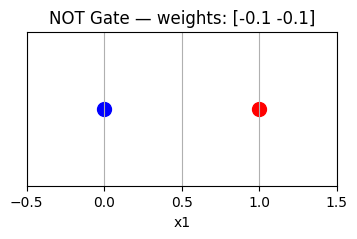

Epoch 2, input [0], target 1, pred 0 -> updated weights: [ 0.  -0.1]


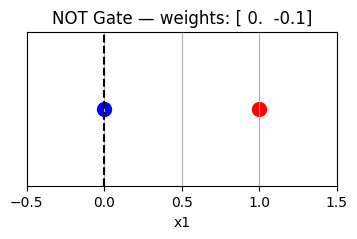

In [ ]:
X_not = np.array([[0],[1]])
y_not = np.array([1,0])

p_not = Perceptron(n_inputs=1, lr=0.1)
p_not.train(X_not, y_not, epochs=10, gate_name="NOT Gate")